In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error



1. ANÁLISIS EXPLORATORIO DE DATOS

Información del Dataset:
Número de registros: 500
Número de variables: 7

Valores nulos por columna:
customer_id           0
age                   0
income                0
visits_per_month      0
satisfaction_score    0
membership_years      0
monthly_spent         0
dtype: int64

Estadísticas Descriptivas:
       customer_id     age   income  visits_per_month  satisfaction_score  \
count       500.00  500.00   500.00            500.00              500.00   
mean        250.50   44.22  2975.26              7.89                3.02   
std         144.48   15.04   981.66              2.69                1.42   
min           1.00   18.00   800.00              1.00                1.00   
25%         125.75   32.00  2285.75              6.00                2.00   
50%         250.50   45.00  2977.48              8.00                3.00   
75%         375.25   57.00  3628.67             10.00                4.00   
max         500.00   69.00  6078.88    

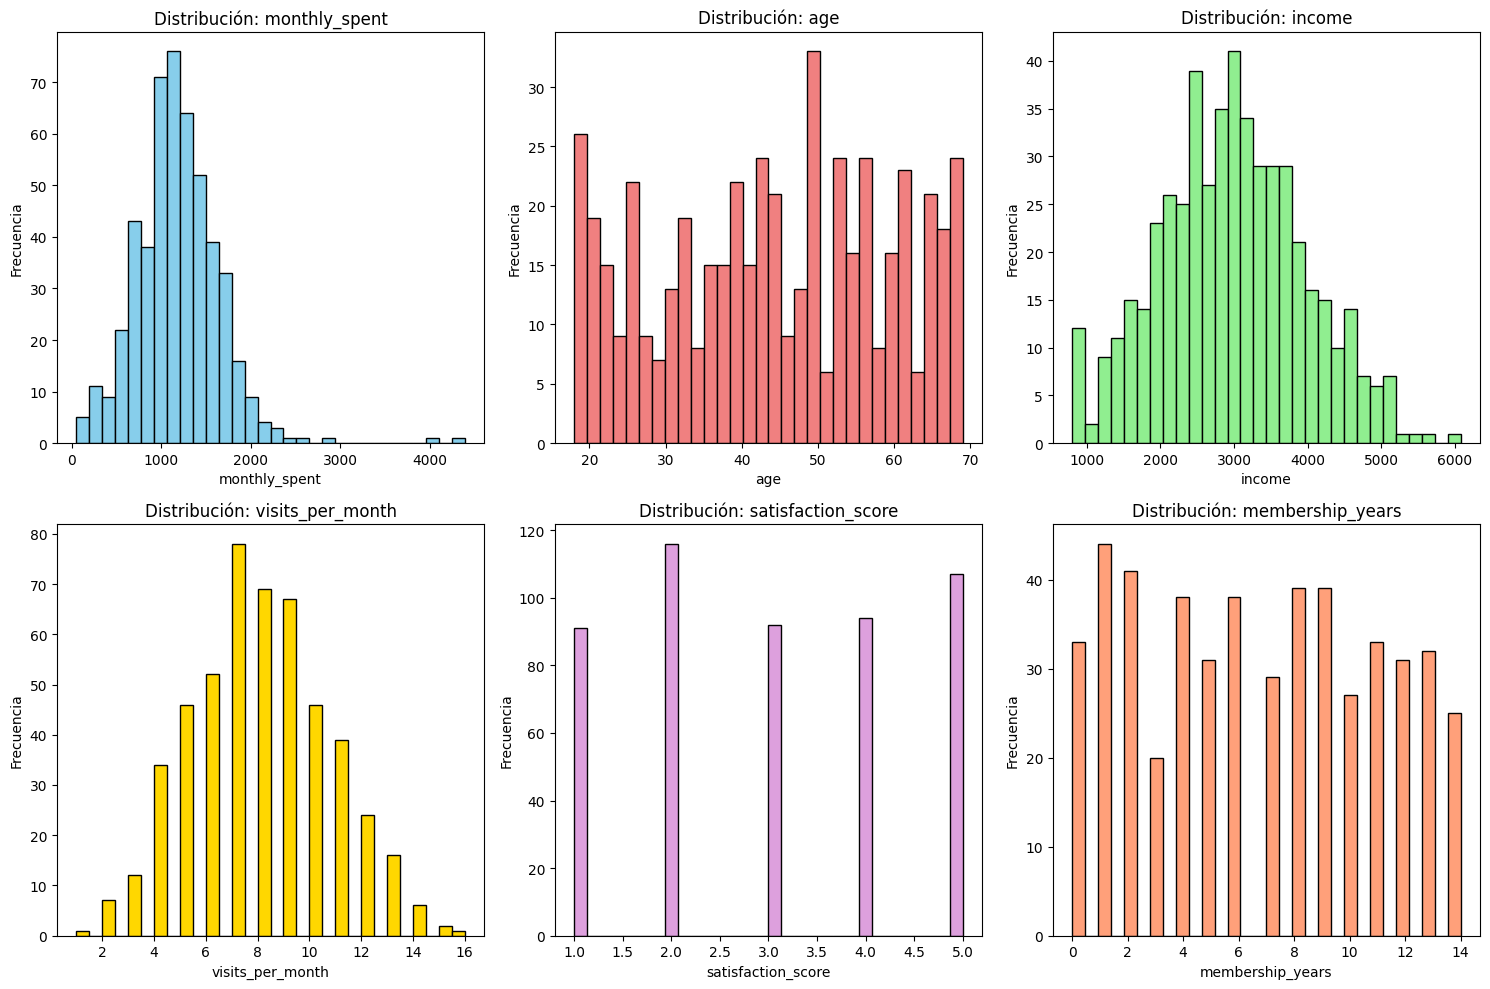


Matriz de Correlación:
                      age  income  visits_per_month  satisfaction_score  \
age                 1.000   0.021             0.016               0.046   
income              0.021   1.000            -0.022              -0.016   
visits_per_month    0.016  -0.022             1.000              -0.062   
satisfaction_score  0.046  -0.016            -0.062               1.000   
membership_years   -0.061   0.116            -0.039               0.009   
monthly_spent       0.006   0.560             0.042               0.212   

                    membership_years  monthly_spent  
age                           -0.061          0.006  
income                         0.116          0.560  
visits_per_month              -0.039          0.042  
satisfaction_score             0.009          0.212  
membership_years               1.000          0.269  
monthly_spent                  0.269          1.000  


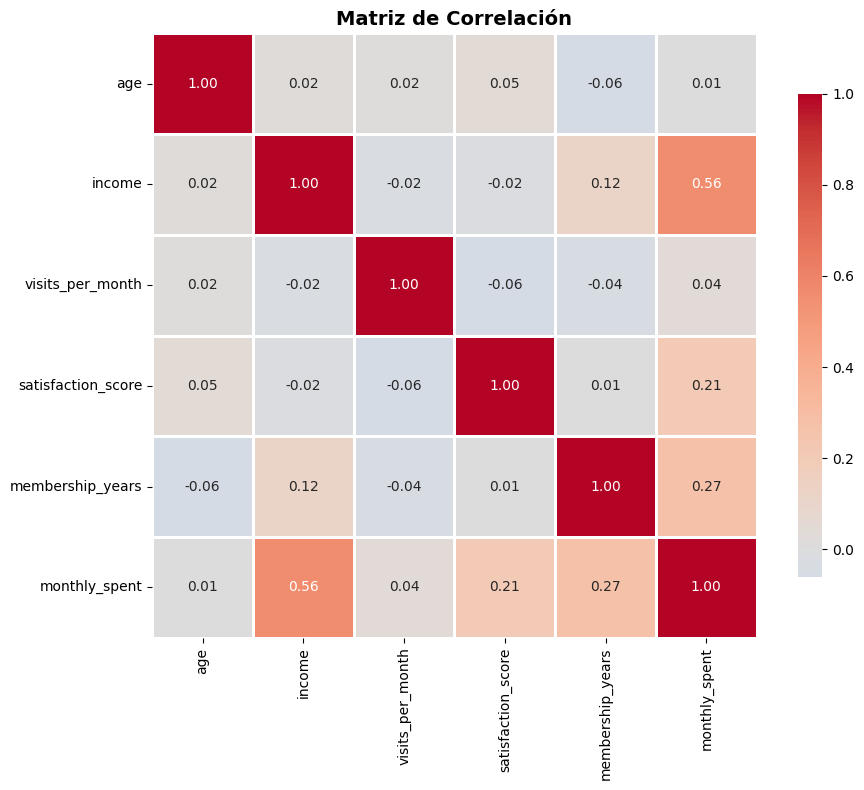


Correlación con monthly_spent:
monthly_spent         1.000000
income                0.559534
membership_years      0.269133
satisfaction_score    0.211600
visits_per_month      0.041673
age                   0.005934
Name: monthly_spent, dtype: float64


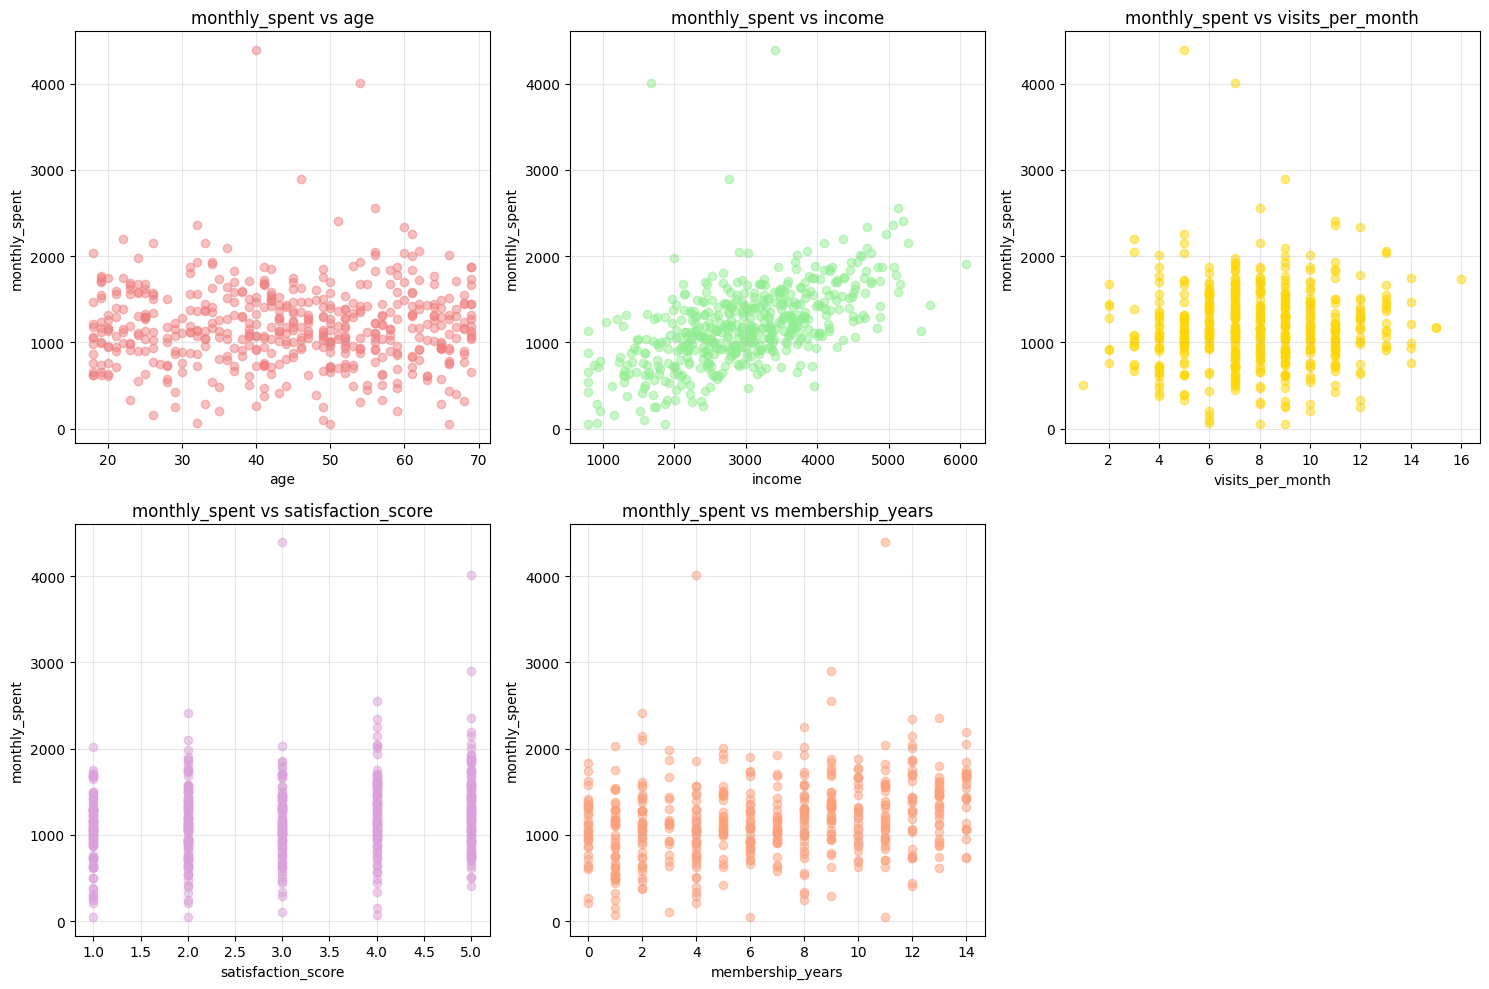

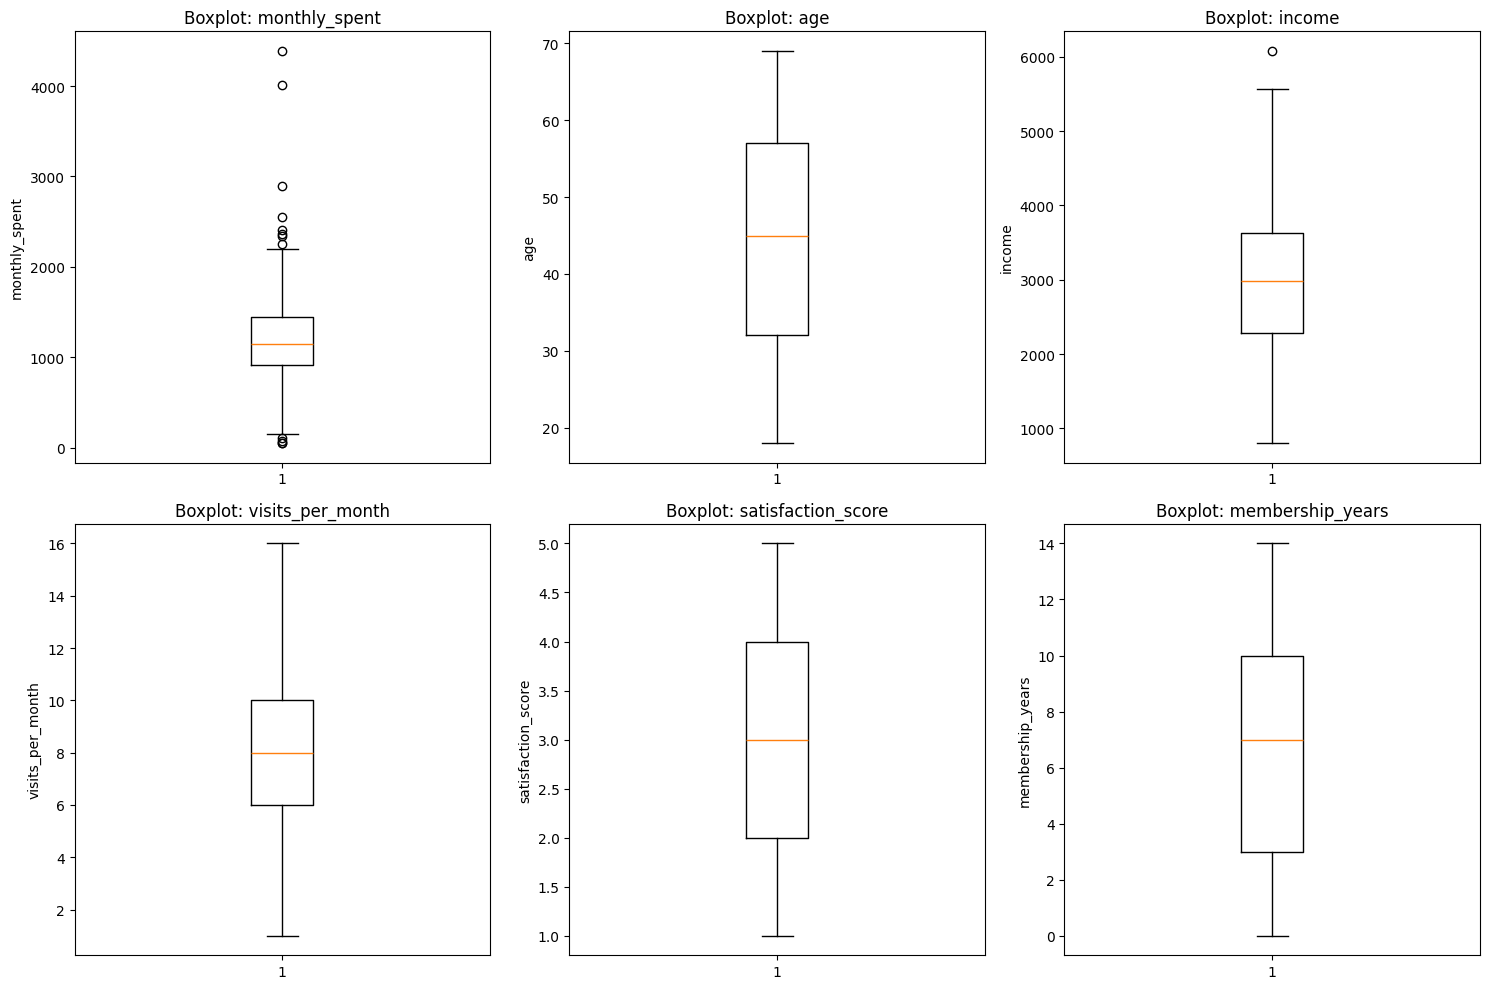

<Figure size 640x480 with 0 Axes>


 Matriz de Correlación:
                      age  income  visits_per_month  satisfaction_score  \
age                 1.000   0.021             0.016               0.046   
income              0.021   1.000            -0.022              -0.016   
visits_per_month    0.016  -0.022             1.000              -0.062   
satisfaction_score  0.046  -0.016            -0.062               1.000   
membership_years   -0.061   0.116            -0.039               0.009   
monthly_spent       0.006   0.560             0.042               0.212   

                    membership_years  monthly_spent  
age                           -0.061          0.006  
income                         0.116          0.560  
visits_per_month              -0.039          0.042  
satisfaction_score             0.009          0.212  
membership_years               1.000          0.269  
monthly_spent                  0.269          1.000  


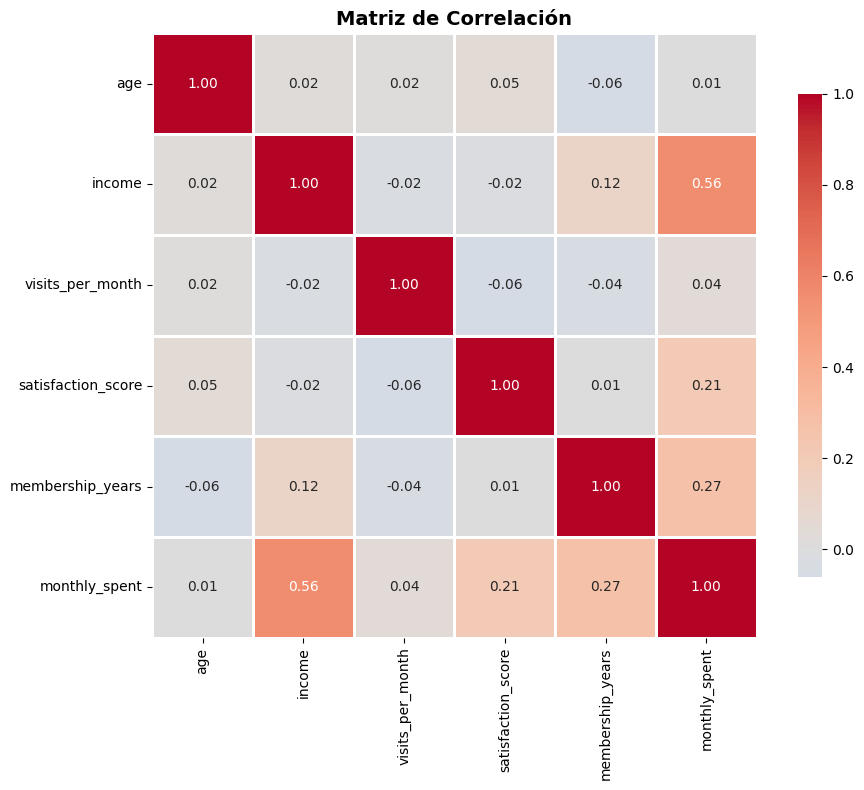


 Correlación con monthly_spent:
monthly_spent         1.000000
income                0.559534
membership_years      0.269133
satisfaction_score    0.211600
visits_per_month      0.041673
age                   0.005934
Name: monthly_spent, dtype: float64


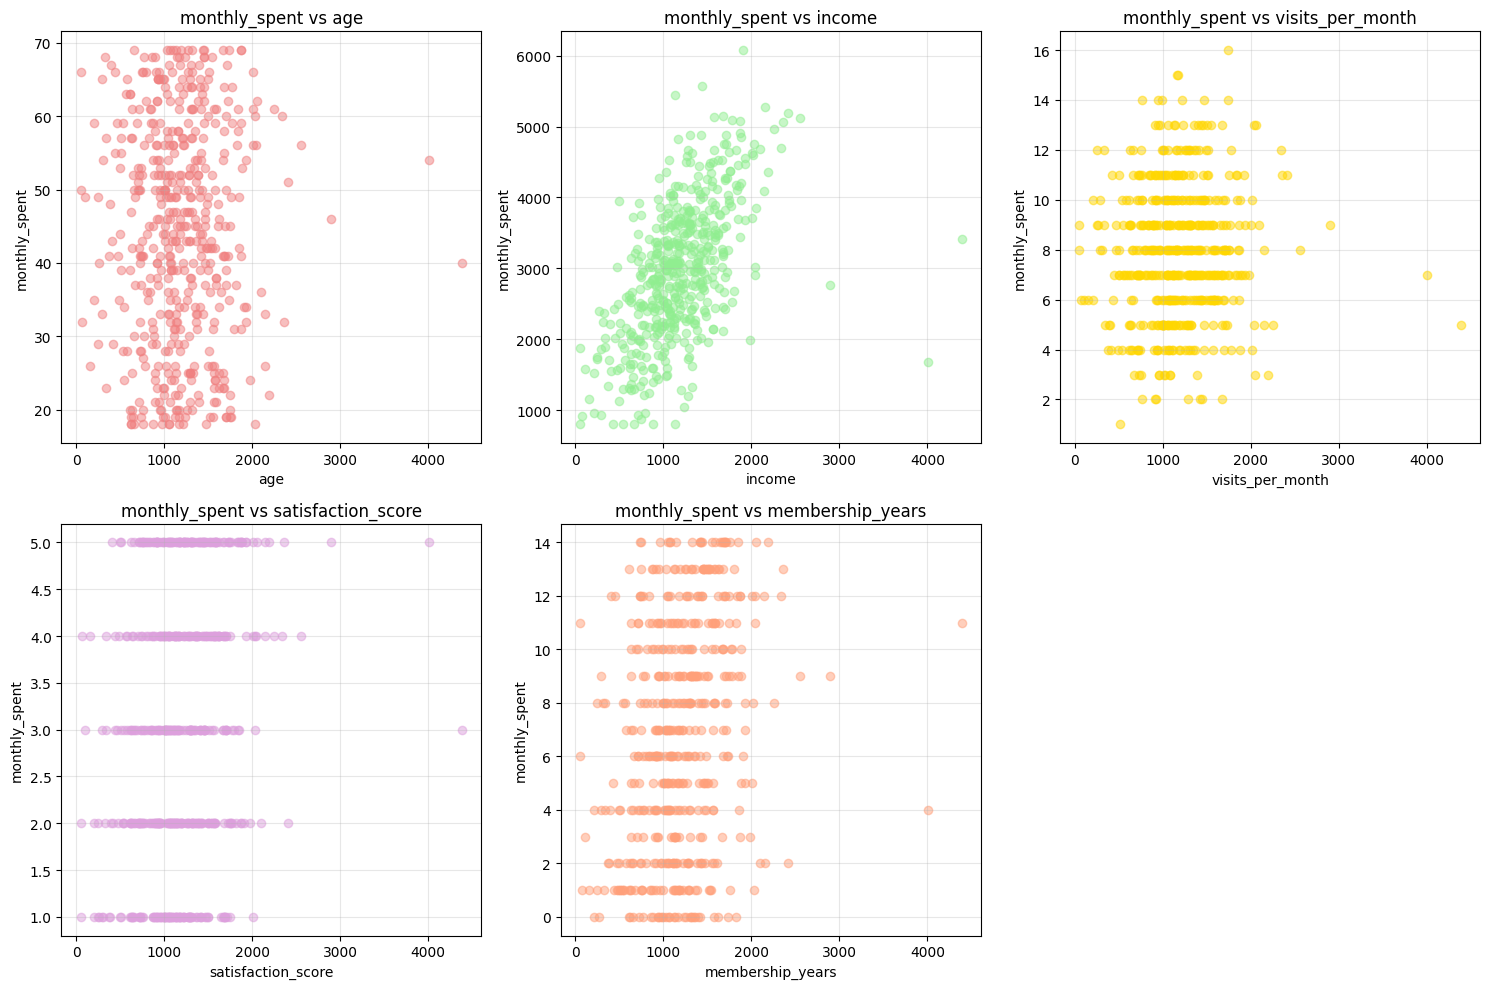

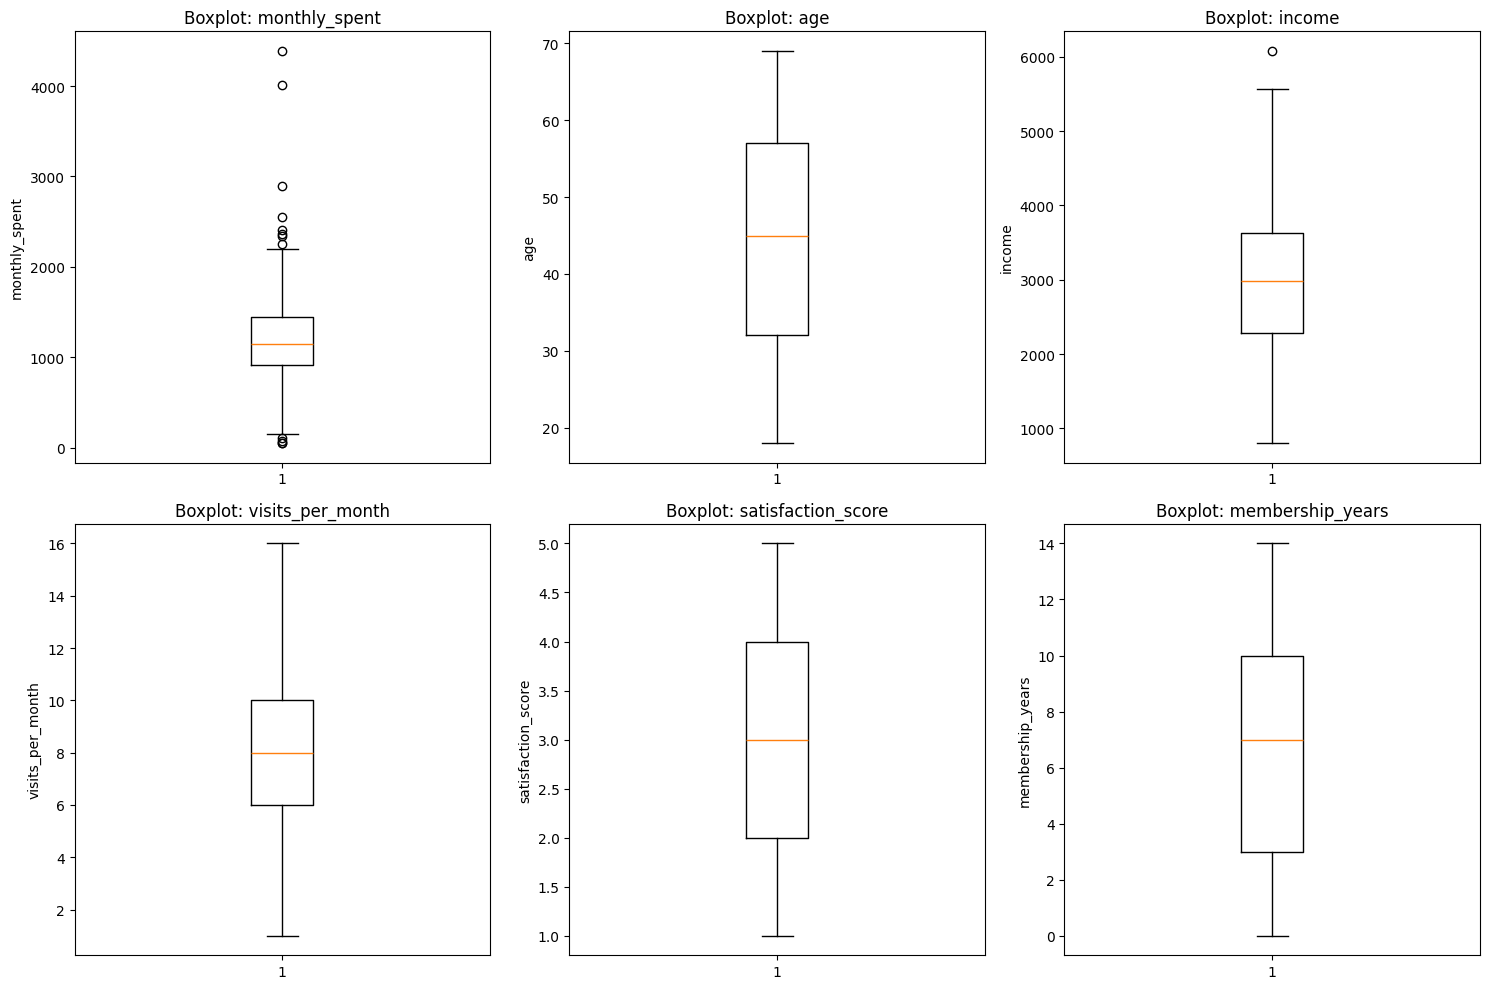

In [2]:
# ======================================================
# 1. Análisis Exploratorio de Datos completo (EDA)
# ======================================================

# Cargar el dataset
df = pd.read_csv("retailboost_customers_regression.csv")

# ======================================================
# 1. EDA COMPLETO
# ======================================================
print("=" * 60)
print("1. ANÁLISIS EXPLORATORIO DE DATOS")
print("=" * 60)

# Información general
print("\nInformación del Dataset:")
print(f"Número de registros: {len(df)}")
print(f"Número de variables: {len(df.columns)}")
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Estadísticas descriptivas
print("\nEstadísticas Descriptivas:")
print(df.describe().round(2))


# ======================================================
# Distribución de variables
# ======================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].hist(df['monthly_spent'], bins=30, edgecolor='black', color='skyblue')
axes[0, 0].set_title('Distribución: monthly_spent')
axes[0, 0].set_xlabel('monthly_spent')
axes[0, 0].set_ylabel('Frecuencia')

axes[0, 1].hist(df['age'], bins=30, edgecolor='black', color='lightcoral')
axes[0, 1].set_title('Distribución: age')
axes[0, 1].set_xlabel('age')
axes[0, 1].set_ylabel('Frecuencia')

axes[0, 2].hist(df['income'], bins=30, edgecolor='black', color='lightgreen')
axes[0, 2].set_title('Distribución: income')
axes[0, 2].set_xlabel('income')
axes[0, 2].set_ylabel('Frecuencia')

axes[1, 0].hist(df['visits_per_month'], bins=30, edgecolor='black', color='gold')
axes[1, 0].set_title('Distribución: visits_per_month')
axes[1, 0].set_xlabel('visits_per_month')
axes[1, 0].set_ylabel('Frecuencia')

axes[1, 1].hist(df['satisfaction_score'], bins=30, edgecolor='black', color='plum')
axes[1, 1].set_title('Distribución: satisfaction_score')
axes[1, 1].set_xlabel('satisfaction_score')
axes[1, 1].set_ylabel('Frecuencia')

axes[1, 2].hist(df['membership_years'], bins=30, edgecolor='black', color='lightsalmon')
axes[1, 2].set_title('Distribución: membership_years')
axes[1, 2].set_xlabel('membership_years')
axes[1, 2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


# ======================================================
# Matriz de correlación
# ======================================================
print("\nMatriz de Correlación:")
correlation_matrix = df.drop('customer_id', axis=1).corr()
print(correlation_matrix.round(3))

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8}
)
plt.title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# ======================================================
# Correlación con la variable objetivo
# ======================================================
print("\nCorrelación con monthly_spent:")
correlations = df.drop('customer_id', axis=1).corr()['monthly_spent'].sort_values(ascending=False)
print(correlations)


# ======================================================
# Scatterplots de variables vs monthly_spent
# ======================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
variables = ['age', 'income', 'visits_per_month', 'satisfaction_score', 'membership_years']
colors = ['lightcoral', 'lightgreen', 'gold', 'plum', 'lightsalmon']

for idx, (var, color) in enumerate(zip(variables, colors)):
    row = idx // 3
    col = idx % 3
    axes[row, col].scatter(df[var], df['monthly_spent'], alpha=0.5, color=color)
    axes[row, col].set_xlabel(var)
    axes[row, col].set_ylabel('monthly_spent')
    axes[row, col].set_title(f'monthly_spent vs {var}')
    axes[row, col].grid(True, alpha=0.3)

axes[1, 2].axis('off')
plt.tight_layout()
plt.show()


# ======================================================
# Boxplots para detectar outliers
# ======================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].boxplot(df['monthly_spent'])
axes[0, 0].set_title('Boxplot: monthly_spent')
axes[0, 0].set_ylabel('monthly_spent')

axes[0, 1].boxplot(df['age'])
axes[0, 1].set_title('Boxplot: age')
axes[0, 1].set_ylabel('age')

axes[0, 2].boxplot(df['income'])
axes[0, 2].set_title('Boxplot: income')
axes[0, 2].set_ylabel('income')

axes[1, 0].boxplot(df['visits_per_month'])
axes[1, 0].set_title('Boxplot: visits_per_month')
axes[1, 0].set_ylabel('visits_per_month')

axes[1, 1].boxplot(df['satisfaction_score'])
axes[1, 1].set_title('Boxplot: satisfaction_score')
axes[1, 1].set_ylabel('satisfaction_score')

axes[1, 2].boxplot(df['membership_years'])
axes[1, 2].set_title('Boxplot: membership_years')
axes[1, 2].set_ylabel('membership_years')

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

# Matriz de correlación 
print("\n Matriz de Correlación:")
correlation_matrix = df.drop("customer_id", axis=1).corr()
print(correlation_matrix.round(3))

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlación con la variable respuesta (nuestra variable objetivo)
print("\n Correlación con monthly_spent:")
correlations = df.drop('customer_id', axis=1).corr()['monthly_spent'].sort_values(ascending=False)
print(correlations)

# Scatterplots de variables versus monthly_spent
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
variables = ['age', 'income', 'visits_per_month', 'satisfaction_score', 'membership_years']
colors = ['lightcoral', 'lightgreen', 'gold', 'plum', 'lightsalmon',]

for idx, (var, color) in enumerate(zip(variables, colors)):
    row = idx // 3
    col = idx % 3
    axes[row,col].scatter(df['monthly_spent'], df[var], alpha=0.5, color=color)
    axes[row,col].set_xlabel(var)
    axes[row,col].set_ylabel('monthly_spent')
    axes[row,col].set_title(f'monthly_spent vs {var}')
    axes[row,col].grid(True, alpha=0.3)

axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

# Boxplots para detectar outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].boxplot(df['monthly_spent'])
axes[0, 0].set_title('Boxplot: monthly_spent')
axes[0, 0].set_ylabel('monthly_spent')

axes[0, 1].boxplot(df['age'])
axes[0, 1].set_title('Boxplot: age')
axes[0, 1].set_ylabel('age')

axes[0, 2].boxplot(df['income'])
axes[0, 2].set_title('Boxplot: income')
axes[0, 2].set_ylabel('income')

axes[1, 0].boxplot(df['visits_per_month'])
axes[1, 0].set_title('Boxplot: visits_per_month')
axes[1, 0].set_ylabel('visits_per_month')

axes[1, 1].boxplot(df['satisfaction_score'])
axes[1, 1].set_title('Boxplot: satisfaction_score')
axes[1, 1].set_ylabel('satisfaction_score')

axes[1, 2].boxplot(df['membership_years'])
axes[1, 2].set_title('Boxplot: membership_years')
axes[1, 2].set_ylabel('membership_years')

plt.tight_layout()
plt.show()


In [3]:
# ======================================================
# 2. Modelos de regresión
# ======================================================
print("\n" + "=" * 60)
print("2. AJUSTE DE MODELOS")
print("=" * 60)

# Preparar datos
X = df[['age', 'income', 'visits_per_month', 'satisfaction_score', 'membership_years']]
y = df['monthly_spent']

# Dividir en train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Modelo de regresión lineal simple (usando income)
# Seleccionamos la variable income porque es la que
# muestra la mayor correlación con monthly_spent.
X_train_simple = X_train[['income']]
X_test_simple = X_test[['income']]

model_simple = LinearRegression()
model_simple.fit(X_train_simple, y_train) # entrenamos el modelo
y_pred_simple = model_simple.predict(X_test_simple)

print("\nModelo de Regresión Lineal Simple (income):")
print(f"Coeficiente: {model_simple.coef_[0]:.4f}")
print(f"Intercepto: {model_simple.intercept_:.4f}")

# Modelo de regresión lineal múltiple
# Hacemos uso de todas las variables predictoras disponibles.
model_multiple = LinearRegression()
model_multiple.fit(X_train, y_train)

y_pred_multiple = model_multiple.predict(X_test)

print("\nModelo de Regresión Lineal Múltiple:")
print("Coeficientes:")
for col, coef in zip(X.columns, model_multiple.coef_):
    print(f" {col}: {coef:.4f}")
print(f"Intercepto: {model_multiple.intercept_:.4f}")


# Si no hay ingreso (x=0), el gasto mensual (inversión) 
# sería 365.7807.
# Por cada dólar que se invierte, el gasto mensual 
# aumenta en 0.2732 unidades.



2. AJUSTE DE MODELOS

Modelo de Regresión Lineal Simple (income):
Coeficiente: 0.2732
Intercepto: 365.7807

Modelo de Regresión Lineal Múltiple:
Coeficientes:
 age: 0.0816
 income: 0.2594
 visits_per_month: 14.7546
 satisfaction_score: 71.4981
 membership_years: 21.9407
Intercepto: -78.5774


In [4]:
# ======================================================
# 3. Métricas de evaluación
# ======================================================
print("\n" + "=" * 60)
print("3. Métricas en conjunto de prueba")
print("=" * 60)

# Métricas modelo simple
r2_simple = r2_score(y_test, y_pred_simple)
mae_simple = mean_absolute_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_simple))

print("\nModelo simple:")
print(f"R²: {r2_simple:.4f}")
print(f"MAE: {mae_simple:.4f}")
print(f"RMSE: {rmse_simple:.4f}")

# Métricas modelo múltiple
r2_multiple = r2_score(y_test, y_pred_multiple)
mae_multiple = mean_absolute_error(y_test, y_pred_multiple)
rmse_multiple = np.sqrt(mean_squared_error(y_test, y_pred_multiple))

print("\nModelo múltiple:")
print(f"R²: {r2_multiple:.4f}")
print(f"MAE: {mae_multiple:.4f}")
print(f"RMSE: {rmse_multiple:.4f}")

print("\nInterpretación:")
print(f"El modelo múltiple explica el {r2_multiple*100:.2f}% de la variabilidad de monthly_spent.")
print(f"En promedio, las predicciones tienen un error absoluto de $: {mae_multiple:.2f}")
print(f"y un error cuadrático medio de $ {rmse_multiple:.2f}.")


3. Métricas en conjunto de prueba

Modelo simple:
R²: 0.2236
MAE: 273.4068
RMSE: 435.0590

Modelo múltiple:
R²: 0.3397
MAE: 240.6932
RMSE: 401.2071

Interpretación:
El modelo múltiple explica el 33.97% de la variabilidad de monthly_spent.
En promedio, las predicciones tienen un error absoluto de $: 240.69
y un error cuadrático medio de $ 401.21.


In [7]:
# =========================================================
# 4. REGRESIÓN POLINÓMICA
# =========================================================

print("\n" + "=" * 60)
print("4. Regresión polinómica")
print("=" * 60)

# Regresión polinómica de grado 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)
y_pred_poly = model_poly.predict(X_test_poly)

r2_poly = r2_score(y_test, y_pred_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print("\nModelo Polinómico (grado 2):")
print(f"R²: {r2_poly:.4f}")
print(f"MAE: {mae_poly:.4f}")
print(f"RMSE: {rmse_poly:.4f}")


4. Regresión polinómica

Modelo Polinómico (grado 2):
R²: 0.3143
MAE: 247.0409
RMSE: 408.8484



5. VERIFICACIÓN DE SUPUESTOS


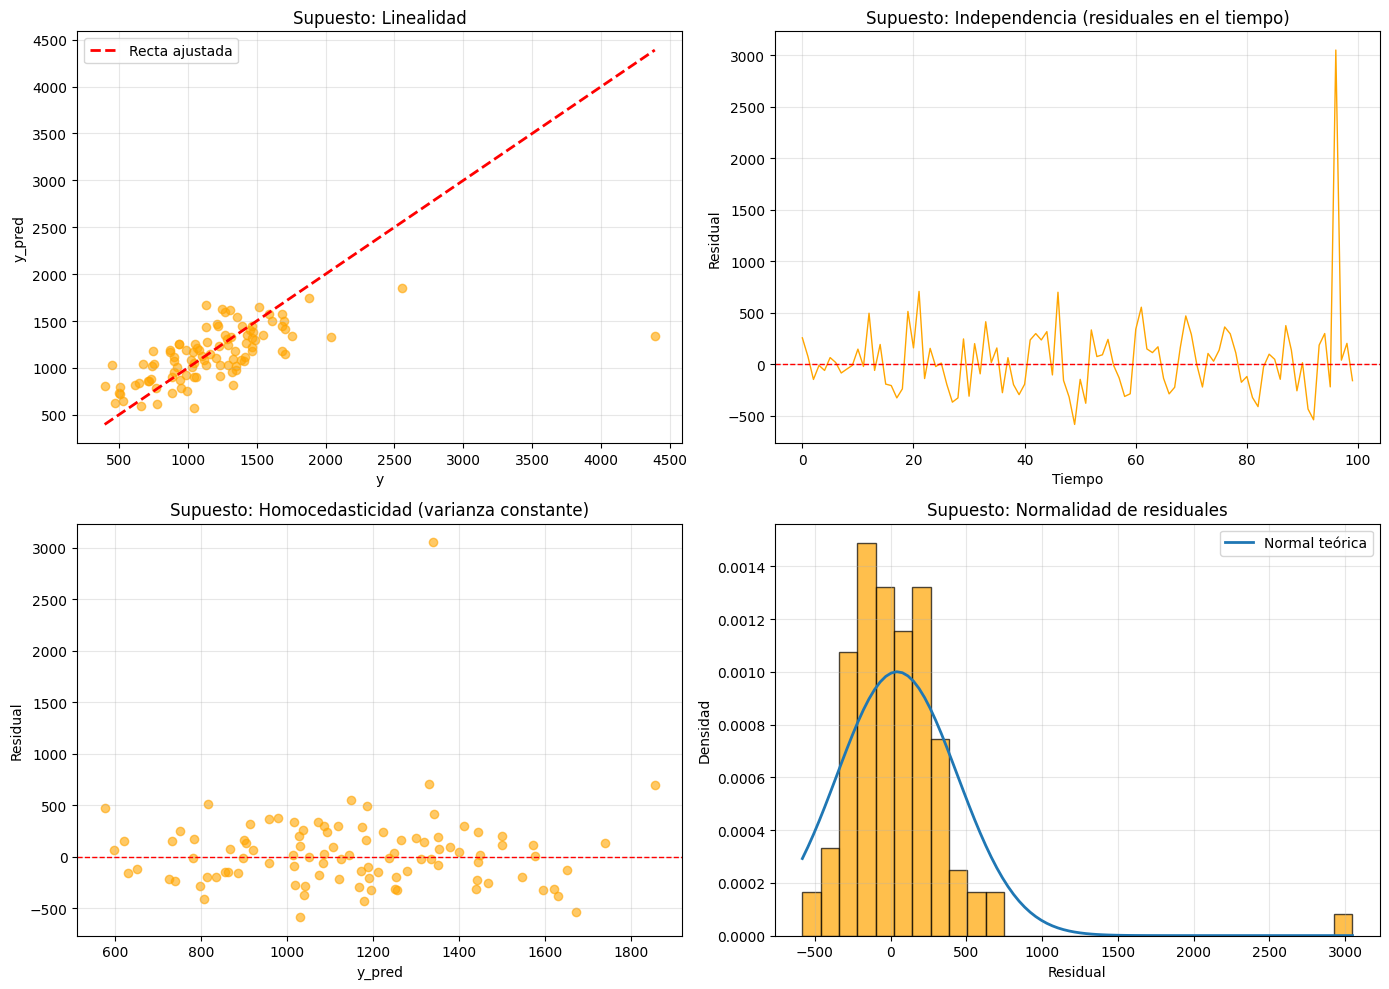

In [6]:
# =========================================================
# 5. Visualización de supuestos
# =========================================================

print("\n" + "=" * 60)
print("5. VERIFICACIÓN DE SUPUESTOS")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: y vs y_pred (Linealidad)
axes[0, 0].scatter(y_test, y_pred_multiple, alpha=0.6, color='orange')
axes[0, 0].plot([y_test.min(), y_test.max()],
                [y_test.min(), y_test.max()],
                'r--', lw=2, label='Recta ajustada')
axes[0, 0].set_xlabel('y')
axes[0, 0].set_ylabel('y_pred')
axes[0, 0].set_title('Supuesto: Linealidad')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Residuales en el tiempo (Independencia)
residuals = y_test.values - y_pred_multiple
axes[0, 1].plot(residuals, color='orange', linewidth=1)
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=1)
axes[0, 1].set_xlabel('Tiempo')
axes[0, 1].set_ylabel('Residual')
axes[0, 1].set_title('Supuesto: Independencia (residuales en el tiempo)')
axes[0, 1].grid(True, alpha=0.3)

# Gráfico 3: Residuales vs y_pred (Homocedasticidad)
axes[1, 0].scatter(y_pred_multiple, residuals, alpha=0.6, color='orange')
axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=1)
axes[1, 0].set_xlabel('y_pred')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].set_title('Supuesto: Homocedasticidad (varianza constante)')
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 4: Histograma de residuales (Normalidad)
axes[1, 1].hist(residuals, bins=30, edgecolor='black',
                color='orange', alpha=0.7, density=True)

mu, sigma = residuals.mean(), residuals.std()
x = np.linspace(residuals.min(), residuals.max(), 100)
axes[1, 1].plot(
    x,
    1 / (sigma * np.sqrt(2 * np.pi)) *
    np.exp(-0.5 * ((x - mu) / sigma) ** 2),
    linewidth=2,
    label='Normal teórica'
)

axes[1, 1].set_xlabel('Residual')
axes[1, 1].set_ylabel('Densidad')
axes[1, 1].set_title('Supuesto: Normalidad de residuales')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


6. COMPARACIÓN DE MODELOS


              Modelo       R²        MAE       RMSE
    Regresión Simple 0.223575 273.406780 435.059049
  Regresión Múltiple 0.339701 240.693186 401.207066
Regresión Polinómica 0.314310 247.040878 408.848360




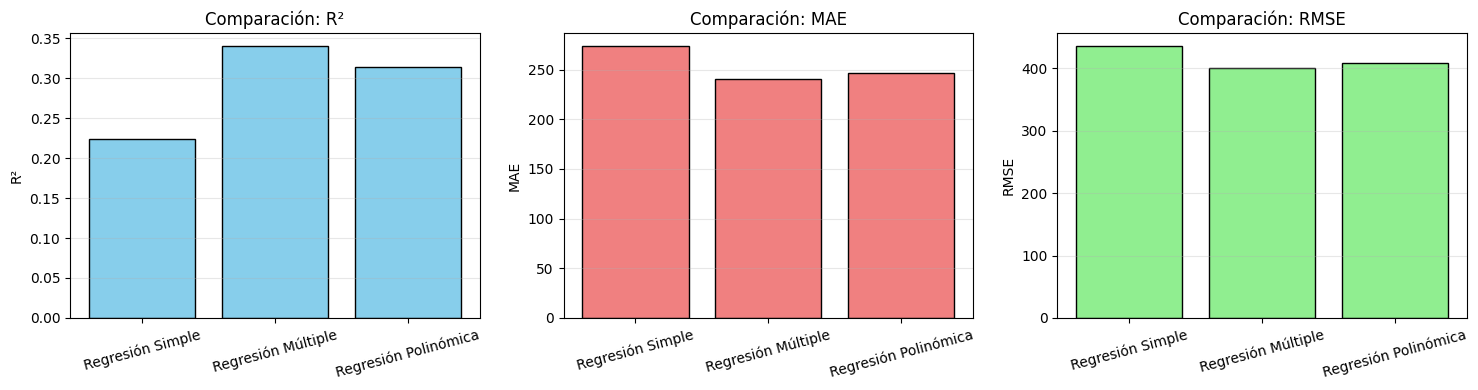

INTERPRETACIÓN DE RESULTADOS

📌 VARIABLES MÁS INFLUYENTES:
------------------------------------------------------------
satisfaction_score  : 71.4981 (positivo)
membership_years    : 21.9407 (positivo)
visits_per_month    : 14.7546 (positivo)
income              : 0.2594 (positivo)
age                 : 0.0816 (positivo)

Las variables con mayor impacto absoluto son:
 - satisfaction_score
 - membership_years
 - visits_per_month

📌 CALIDAD DEL AJUSTE:
------------------------------------------------------------
R² = 0.3397 → El modelo explica el 33.97% de la variabilidad
✖ Ajuste POBRE

📌 RAZONABILIDAD DE ERRORES:
------------------------------------------------------------
Gasto promedio: $1189.94
MAE: $240.69 (20.23% del gasto promedio)
RMSE: $401.21 (33.72% del gasto promedio)
⚠ Errores ALTOS (>20% del promedio)

ANÁLISIS COMPLETADO


In [8]:
# =========================================================
# 6. Tabla comparativa
# =========================================================

print("\n" + "=" * 60)
print("6. COMPARACIÓN DE MODELOS")
print("=" * 60)

# Crear tabla resumen
comparison = pd.DataFrame({
    'Modelo': ['Regresión Simple', 'Regresión Múltiple', 'Regresión Polinómica'],
    'R²': [r2_simple, r2_multiple, r2_poly],
    'MAE': [mae_simple, mae_multiple, mae_poly],
    'RMSE': [rmse_simple, rmse_multiple, rmse_poly]
})

print("\n")
print(comparison.to_string(index=False))
print("\n")

# Visualizar comparación
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = comparison['Modelo']
metrics = ['R²', 'MAE', 'RMSE']
colors = ['skyblue', 'lightcoral', 'lightgreen']

for i, metric in enumerate(metrics):
    axes[i].bar(models, comparison[metric],
                color=colors[i], edgecolor='black')
    axes[i].set_title(f'Comparación: {metric}')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("=" * 60)
print("INTERPRETACIÓN DE RESULTADOS")
print("=" * 60)

print("\n📌 VARIABLES MÁS INFLUYENTES:")
print("-" * 60)

coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model_multiple.coef_,
    'Impacto_Abs': np.abs(model_multiple.coef_)
}).sort_values('Impacto_Abs', ascending=False)

for idx, row in coef_df.iterrows():
    print(f"{row['Variable']:<20}: {row['Coeficiente']:.4f} "
          f"{'(positivo)' if row['Coeficiente'] > 0 else '(negativo)'}")

print("\nLas variables con mayor impacto absoluto son:")
top_vars = coef_df.head(3)
for idx, row in top_vars.iterrows():
    print(f" - {row['Variable']}")

print("\n📌 CALIDAD DEL AJUSTE:")
print("-" * 60)
print(f"R² = {r2_multiple:.4f} → El modelo explica el {r2_multiple*100:.2f}% de la variabilidad")

if r2_multiple >= 0.8:
    print("✔ Ajuste EXCELENTE")
elif r2_multiple >= 0.6:
    print("✔ Ajuste BUENO")
elif r2_multiple >= 0.4:
    print("⚠ Ajuste MODERADO")
else:
    print("✖ Ajuste POBRE")

print("\n📌 RAZONABILIDAD DE ERRORES:")
print("-" * 60)

mean_spending = y_test.mean()
print(f"Gasto promedio: ${mean_spending:.2f}")
print(f"MAE: ${mae_multiple:.2f} ({(mae_multiple/mean_spending)*100:.2f}% del gasto promedio)")
print(f"RMSE: ${rmse_multiple:.2f} ({(rmse_multiple/mean_spending)*100:.2f}% del gasto promedio)")

if (mae_multiple/mean_spending) <= 0.1:
    print("✔ Errores MUY RAZONABLES (<10% del promedio)")
elif (mae_multiple/mean_spending) <= 0.2:
    print("✔ Errores RAZONABLES (<20% del promedio)")
else:
    print("⚠ Errores ALTOS (>20% del promedio)")

print("\n" + "=" * 60)
print("ANÁLISIS COMPLETADO")

### El modelo múltiple mostró una mejora significativa en R² y una reducción en RMSE respecto al modelo simple, lo que indica que el gasto mensual es un fenómeno multivariado. Sin embargo, el error residual sugiere que existen factores adicionales no capturados. Desde una perspectiva de negocio, el modelo es suficientemente robusto para segmentación y proyección, aunque podría optimizarse con modelos no lineales.